# 03 - Modeliranje 

## Uvodne napomene

### Cilj

U ovom notebook-u, biće ispitano da li se osobine odgovora na kalcijum na nivou neurona mogu iskoristiti za razlikovanje fenotipa eksperimentalnih grupa sa različitim neurodegenerativnim stanjima: ALS, SMA i kontrola.

Analiza obuhvata nekoliko skupova osobina:
1. Status odgovora na tretman CSF-om
2. Osobine referentnog odgovora na K+ tretman
3. Osobine na nivou pikova u odgovoru na CSF i K+
4. Odnosi karakteristika odgovora na CSF i K+
5. Osobine izvedene iz fita odgovora

### Ograničenja

Osnovna jedinica beleženja podataka u originalnom snimanju jeste ROI - region od interesa. To je površina koja je ručno odabrana tako da obuhvata pojedinačnu vijabilnu ćeliju, i sa koje se očitava intenzitet fluorescencije. Sve ćelije u datom eksperimentu su izložene istim uslovima, te se zato ROI iz istog eksperimenta ne mogu posmatrati kao nezavisni biološki uzorci. Set podataka na kom radimo sadrži **997 ROI** iz **6 eksperimenata**, u kojima je korišćena CSF poreklom od **5 pacijenata**.

Imajući ovo u vidu, modeli koji mogu biti konstruisani imaće određena ograničenja:
- Nasumična ukrštena validacija će verovatno davati optimistične rezultate.
- Efekti poreklom od datog eksperimenta i/ili pacijenta će potencijalno imati veći uticaj od uopštenijih efekata poreklom od bolesti.
- Modeli će se posmatrati kao oruđe za mogućnost razdvajanja klasa unutar datog seta podataka, ali se iz njih ne mogu pouzdano izvoditi zaključci koji se mogu generalizovati.

## Uvoz biblioteka i početno podešavanje

In [1]:
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# Random seed
RANDOM_STATE = 42

In [3]:
# Verzije softvera
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.9
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0


In [4]:
# Direktorije i učitavanje podataka
PROJECT_ROOT = Path.cwd().parent

EXTRACTED_DIR = PROJECT_ROOT / "data" / "extracted"

ENGINEERED_TABLE_PATH = (
    EXTRACTED_DIR / "roi_features_engineered.csv"
)

df = pd.read_csv(ENGINEERED_TABLE_PATH)

print("Učitano:", ENGINEERED_TABLE_PATH)
print("Dimenzije:", df.shape)

Učitano: /home/pera/Faks/Master/MasterProjekatPetarJ/data/extracted/roi_features_engineered.csv
Dimenzije: (997, 84)


In [5]:
# Provera integriteta
print("Broj jedinstvenih zapisa:", df["record_id"].nunique())
print("Duplirani zapisi:", df["record_id"].duplicated().sum())
print("Nedostajuće oznake klasa:", df["class_label"].isna().sum())
print("Nedostajuće oznake eksperimenata:", df["experiment_id"].isna().sum())
print("Nedostajuće oznake pacijenata:", df["patient_id"].isna().sum())

Broj jedinstvenih zapisa: 997
Duplirani zapisi: 0
Nedostajuće oznake klasa: 0
Nedostajuće oznake eksperimenata: 0
Nedostajuće oznake pacijenata: 0


In [6]:
df["class_label"].value_counts()

class_label
SMA        545
ALS        269
Control    183
Name: count, dtype: int64

In [7]:
df.groupby(
    ["class_label", "patient_id", "experiment_id"]
).size()

class_label  patient_id  experiment_id    
ALS          3           patient_3_exp_1      163
             4           patient_4_exp_1      106
Control      7           patient_7_exp_1      183
SMA          10a         patient_10a_exp_1    230
             10b         patient_10b_exp_1    171
                         patient_10b_exp_2    144
dtype: int64

Tabele su u skladu sa očekivanjima. Sada ćemo preći na modeliranje našeg seta podataka.

## Definisanje najvažnijih osobina kalcijumskog odgovora

Prvo ćemo se fokusirati na osobine koje se direktno tiču kalcijumskog odgovora, a kasnije ćemo u modele uključiti i parametre fita za svaki odgovor.

In [8]:
# Promenljiva odgovora
TARGET_COLUMN = "class_label"

# Oznake eksperimenta i pacijenta
EXPERIMENT_GROUP_COLUMN = "experiment_id"
PATIENT_GROUP_COLUMN = "patient_id"

y = df[TARGET_COLUMN].copy()

experiment_groups = df[EXPERIMENT_GROUP_COLUMN].copy()
patient_groups = df[PATIENT_GROUP_COLUMN].copy()

In [9]:
# Eksperimentalne grupe
group_structure = (
    df[
        [
            "class_label",
            "patient_id",
            "experiment_id",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "class_label",
            "patient_id",
            "experiment_id",
        ]
    )
)

group_structure

,class_label,patient_id,experiment_id
545,ALS,3,patient_3_exp_1
708,ALS,4,patient_4_exp_1
814,Control,7,patient_7_exp_1
0,SMA,10a,patient_10a_exp_1
230,SMA,10b,patient_10b_exp_1
401,SMA,10b,patient_10b_exp_2


Ovde vidimo jedno od najvećih ograničenja naših podataka - kontrolna klasa obuhvata samo jedan eksperiment i jednog pacijenta.

Sada ćemo definisati najvažnije osobine podataka:
- Osobine statusa odgovora: `response_status_features`;
- Osobine referentnog K+ odgovora: `k_reference_features`;
- Osnovne osobine CSF odgovora: `csf_response_features`;
- Kombinovane osobine na nivou pikova: `combined_peak_features`;
- Kombinovane osobine na nivou pikova, zajedno sa odnosima amplituda i integrala: `combined_ratio_features`.

In [10]:
response_status_features = [
    "csf_response_detected_int",
    "csf_multiple_responses_int",
]

In [11]:
k_reference_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",
]

In [12]:
csf_response_features = [
    "csf_response_detected_int",
    "csf_multiple_responses_int",
    "csf_amplitude",
    "csf_half_width",
    "csf_integral",
]

In [13]:
combined_peak_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",

    "csf_response_detected_int",
    "csf_multiple_responses_int",
    "csf_amplitude",
    "csf_half_width",
    "csf_integral",
]

In [14]:
combined_ratio_features = [
    *combined_peak_features,
    "csf_to_k_amplitude_ratio",
    "csf_to_k_integral_ratio",
]

In [15]:
# Prikupljanje svih skupova u rečnik
feature_sets = {
    "response_status": response_status_features,
    "k_reference": k_reference_features,
    "csf_response": csf_response_features,
    "combined_peak": combined_peak_features,
    "combined_with_ratios": combined_ratio_features,
}

In [16]:
# Provera da li su sve kolone tu
for feature_set_name, features in feature_sets.items():
    missing_columns = [
        feature for feature in features
        if feature not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{feature_set_name} sadrži nedostajuće kolone: "
            f"{missing_columns}"
        )

In [17]:
# Provera svih nedostajućih vrednosti
feature_set_summary = []

for feature_set_name, features in feature_sets.items():
    subset = df[features]

    feature_set_summary.append(
        {
            "feature_set": feature_set_name,
            "n_features": len(features),
            "rows_with_any_missing": (
                subset.isna().any(axis=1).sum()
            ),
            "fraction_rows_with_any_missing": (
                subset.isna().any(axis=1).mean()
            ),
            "total_missing_values": (
                subset.isna().sum().sum()
            ),
        }
    )

feature_set_summary = pd.DataFrame(feature_set_summary)

feature_set_summary

,feature_set,n_features,rows_with_any_missing,fraction_rows_with_any_missing,total_missing_values
0,response_status,2,0,0.000000,0
1,k_reference,3,1,0.001003,2
2,csf_response,5,322,0.322969,644
3,combined_peak,8,323,0.323972,646
4,combined_with_ratios,10,323,0.323972,969


### Strategija evaluacije modela

Evaluacija modela biće vršena u tri stadijuma.

#### Faza 1 - *Dummy* osnovica

Tzv. *dummy* klasifikacija donosi performanse koje se dobijaju predikcijom isključivo na osnovu učestalosti klasa.

#### Faza 2 - Ukrštena validacija na nivou ROI 

Stratifikovana ukrštena validacija koristi se kao oruđe za ispitivanje mogućnosti razdvajanja klasa unutar datog seta podataka. Očekuju se optimisitčni rezultati iz prostog razloga što se ROI iz istih eksperimenata pojavljuju u različitim podskupovima/foldovima.

#### Faza 3 - Analize senzitivnosti na grupe

Oznake eksperimenata i pacijenata koriste se da bi se ispitalo da li performanse klasifikacije primarno zavise od efekata uslova datog eksperimenta.

## Modeli (direktni parametri odgovora)

In [18]:
# Inicijalni CV objekat
roi_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

### *Dummy* klasifikator

In [19]:
# Parametri evaluacije
SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

Primarni fokus biće na makro F1 (macro F1) vrednosti i balansiranoj tačnosti (balanced accuracy).

\begin{equation}
    Macro \space F1 = \frac{F1_{ALS}+F1_{SMA}+F1_{Control}}{3}
\end{equation}

gde je $F1$ za svaku klasu:

\begin{equation}
    F1 = 2 \times \frac{precision \times recall}{precision+recall}
\end{equation}

pri čemu važi:

\begin{equation}
    Precision = \frac{Correct \space predictions \space of \space a \space class}{All \space predictions \space of \space that \space class}
\end{equation}

kao i:

\begin{equation}
    Recall = \frac{Correctly \space identified \space members \space of \space a \space class}{All \space actual \space members \space of \space that \space class}
\end{equation}

Balansirana tačnost računa se kao:

\begin{equation}
    Balanced \space accuracy = \frac{Recall_{ALS}+Recall_{SMA}+Recall_{Control}}{3}
\end{equation}

gde je tačnost (Accuracy) za svaku klasu:

\begin{equation}
    Accuracy = \frac{Correct \space predictions}{All \space predictions}
\end{equation}

Obična tačnost (Accuracy) posmatraće se kao sekundarni pokazatelj performansi.

In [20]:
# Provera dummy modela
X_dummy = np.zeros((len(df), 1)) # ne zahteva prave prediktore
                                 # ali svejedno očekuje X matriks
 
dummy_model = DummyClassifier(
    strategy="most_frequent",
)

dummy_cv_results = cross_validate(
    estimator=dummy_model,
    X=X_dummy,
    y=y,
    cv=roi_cv,
    scoring=SCORING,
    return_train_score=False,
    error_score="raise",
)

In [21]:
# Prikaz rezultata
dummy_summary = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
        ],
        "mean_cv_score": [
            dummy_cv_results["test_accuracy"].mean(),
            dummy_cv_results["test_balanced_accuracy"].mean(),
            dummy_cv_results["test_f1_macro"].mean(),
        ],
        "std_cv_score": [
            dummy_cv_results["test_accuracy"].std(),
            dummy_cv_results["test_balanced_accuracy"].std(),
            dummy_cv_results["test_f1_macro"].std(),
        ],
    }
)

dummy_summary

,metric,mean_cv_score,std_cv_score
0,accuracy,0.546643,0.001342
1,balanced_accuracy,0.333333,0.000000
2,f1_macro,0.235625,0.000374


Ovde vidimo zašto obična tačnost sama po sebi nije adekvatan parametar. Usled nebalansiranosti klasa, dummy prediktor koji svaki put predviđa najčešću klasu (SMA) imaće tačnost od `0.547`. Balansirana tačnost, međutim, ima nižu vrednost i predstavlja realniji pokazatelj kvaliteta ovakvog modela.

### Logistička regresija

In [22]:
def make_logistic_pipeline() -> Pipeline:
    """
    Kreira pajplajn obrade i multinomne klasifikacije.

    Nedostajuće vrednosti se popunjavaju medijalnim, dodaju se indikatori
    nedostajućih vrednosti, numeričke promenljive se standardizuju, i 
    fituje se regularizovani klasifikator logističke regresije.
    """
    return Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=False, # Indikator nedostajuće vrednosti već
                                         # prisutan (csf_response_detected_int)
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced", # važno jer SMA dominira
                    max_iter=5000, 
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

Imputacija pomoću medijalnih vrednosti korisna je za osiguravanje od autlajera. Skaliranje je važno zato što različite osobine (amplitude, integrali, odnosi itd.) imaju znatno različite opsege vrednosti. Regularizacija je podrazumevana u sklearn paketu.

In [23]:
def evaluate_feature_set(
    feature_set_name: str,
    features: list[str],
) -> dict:
    """
    Vrši evaluaciju jednog skupa osobina koristeći fiksnu CV podelu.
    """
    X = df[features].copy()

    model = make_logistic_pipeline()

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=roi_cv,
        scoring=SCORING,
        return_train_score=True,
        error_score="raise",
        n_jobs=-1,
    )

    return {
        "feature_set": feature_set_name,
        "n_features": len(features),

        "test_accuracy_mean": (
            cv_results["test_accuracy"].mean()
        ),
        "test_accuracy_std": (
            cv_results["test_accuracy"].std()
        ),

        "test_balanced_accuracy_mean": (
            cv_results["test_balanced_accuracy"].mean()
        ),
        "test_balanced_accuracy_std": (
            cv_results["test_balanced_accuracy"].std()
        ),

        "test_f1_macro_mean": (
            cv_results["test_f1_macro"].mean()
        ),
        "test_f1_macro_std": (
            cv_results["test_f1_macro"].std()
        ),

        "train_balanced_accuracy_mean": (
            cv_results["train_balanced_accuracy"].mean()
        ),
        "train_f1_macro_mean": (
            cv_results["train_f1_macro"].mean()
        ),

        "fit_time_mean": (
            cv_results["fit_time"].mean()
        ),
    }

In [24]:
# Evaluacija svih skupova zasebno
logistic_result_rows = []

for feature_set_name, features in feature_sets.items():
    result = evaluate_feature_set(
        feature_set_name=feature_set_name,
        features=features,
    )

    logistic_result_rows.append(result)

In [25]:
# Spajanje rezultata
logistic_results = (
    pd.DataFrame(logistic_result_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

logistic_results

,feature_set,n_features,test_accuracy_mean,test_accuracy_std,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean,train_f1_macro_mean,fit_time_mean
0,combined_with_ratios,10,0.911729,0.008823,0.921462,0.007253,0.906194,0.008063,0.928622,0.911984,0.029382
1,combined_peak,8,0.910724,0.012102,0.919639,0.013060,0.904484,0.011740,0.925773,0.910124,0.014949
2,k_reference,3,0.745186,0.040902,0.785462,0.034174,0.741086,0.038169,0.784989,0.741067,0.012927
3,csf_response,5,0.697166,0.032488,0.717888,0.018788,0.681844,0.027206,0.726943,0.691217,0.013482
4,response_status,2,0.517618,0.029906,0.501743,0.023541,0.409492,0.032680,0.512564,0.426834,0.037076


In [26]:
# Kompaktnija tabela za vizuelizaciju
logistic_results_display = logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].copy()

logistic_results_display.round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_with_ratios,10,0.912,0.921,0.007,0.906,0.008,0.929
1,combined_peak,8,0.911,0.920,0.013,0.904,0.012,0.926
2,k_reference,3,0.745,0.785,0.034,0.741,0.038,0.785
3,csf_response,5,0.697,0.718,0.019,0.682,0.027,0.727
4,response_status,2,0.518,0.502,0.024,0.409,0.033,0.513


Na osnovu ovih rezultata, možemo primetiti sledeće:

- Status odgovora na CSF nije dovoljno dobar prediktor za klasifikaciju stanja, uprkos dramatičnom odstupanju te osobine kod pacijenta `10b`. Iako pomaže za predikciju ROI upravo iz tih eksperimenata, nije korisna u razlikovanju ALS, kontrole i `10a` SMA. 
- Osobine vezane za K+ samostalno dobro razdvajaju klase, što sugeriše da postoje značajne razlike u ćelijskim kulturama između eksperimenata, u procesu snimanja fluorescencije, eksperimentalnim protokolima, i/ili podložnosti ćelija stimulaciji. Iako ove razlike mogu biti biološki značajne, one nisu povezane sa tretmanom CSF-om.
- Osobine vezane za CSF su osrednje informativne same po sebi, iako su slabiji prediktori u odnosu na osobine K+.
- Kombinovane K+/CSF osobine imaju vrlo dobre performanse. Razlika u odnosu na K+ osobine same po sebi sugeriše da informacije poreklom od CSF-a doprinose prediktivnoj vrednosti modela.
- Međutim, odnosi amplituda i integrala imaju zanemarljiv doprinos. Stoga možemo zaključiti da je najbolji skup osobina `combined_peak`.

Kada je u pitanju razlika u performansi prilikom predikcije uzoraka iz skupa za trening i skupa za testiranje, ona je mala - vrednosti balansirane tačnosti su `0.926` i `0.920`, redom. Možemo zaključiti da naš model ne pokazuje prekomerno fitovanje; međutim, i dalje postoji problem da se ROI iz svakog eksperimenta pojavljuju u podskupovima i za trening i za validaciju.

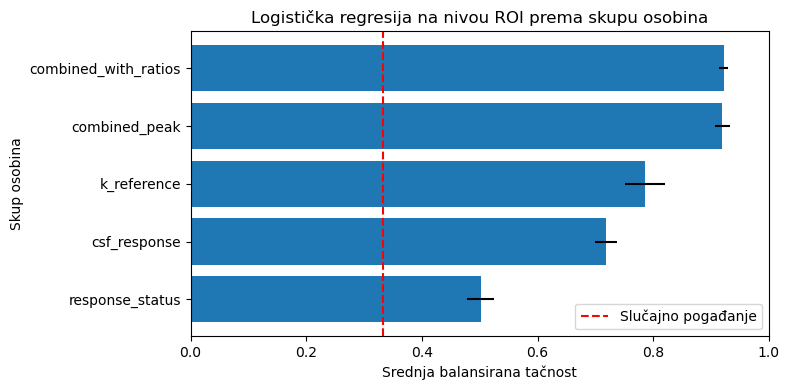

In [27]:
# Vizuelizacija balansirane tačnosti
plot_data = logistic_results.sort_values(
    "test_balanced_accuracy_mean"
)

plt.figure(figsize=(8, 4))

plt.barh(
    plot_data["feature_set"],
    plot_data["test_balanced_accuracy_mean"],
    xerr=plot_data["test_balanced_accuracy_std"],
)

plt.axvline(
    1 / 3,
    linestyle="--",
    color="red",
    label="Slučajno pogađanje",
)

plt.xlabel("Srednja balansirana tačnost")
plt.ylabel("Skup osobina")
plt.title("Logistička regresija na nivou ROI prema skupu osobina")
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Generisanje predikcija na osnovu out-of-fold uzoraka
# koristeći najbolji skup osobina
best_features = feature_sets["combined_peak"]

best_logistic_model = make_logistic_pipeline()

best_oof_predictions = cross_val_predict(
    estimator=best_logistic_model,
    X=df[best_features],
    y=y,
    cv=roi_cv,
    method="predict",
    n_jobs=-1,
)

In [29]:
print(
    classification_report(
        y_true=y,
        y_pred=best_oof_predictions,
        digits=3,
    )
)

              precision    recall  f1-score   support

         ALS      0.879     0.918     0.898       269
     Control      0.844     0.945     0.892       183
         SMA      0.955     0.895     0.924       545

    accuracy                          0.911       997
   macro avg      0.893     0.920     0.905       997
weighted avg      0.914     0.911     0.911       997



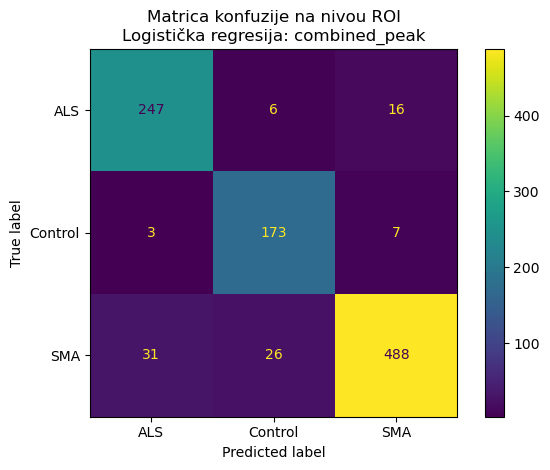

In [30]:
# Matrica konfuzije
ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=best_oof_predictions,
    normalize=None,
)

plt.title(
    f"Matrica konfuzije na nivou ROI\n"
    f"Logistička regresija: combined_peak"
)
plt.tight_layout()
plt.show()

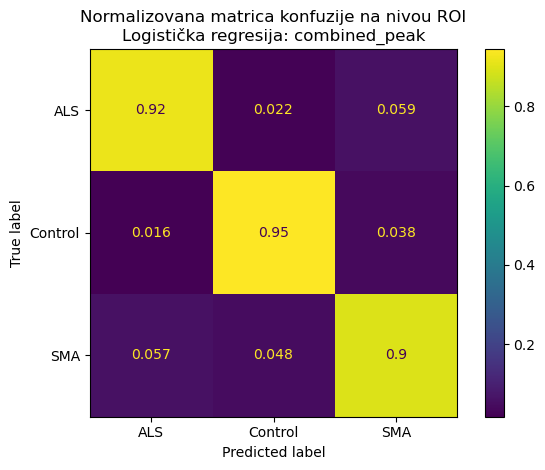

In [31]:
# Normalizovana matrica
ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=best_oof_predictions,
    normalize="true",
)

plt.title(
    f"Normalizovana matrica konfuzije na nivou ROI\n"
    f"Logistička regresija: combined_peak"
)
plt.tight_layout()
plt.show()

Model ima visoku senzitivnost za svaku klasu. Rezultat deluje izbalansirano, iako je SMA dominantna klasa. Ipak, i dalje je važno imati na umu da svaki validacioni podskup ima ROI koji su veoma slični ROI prisutnim u podskupu za trening, budući da potiču iz istog eksperimenta. Visoka senzitivnost za kontrolnu grupu je, stoga, pre svega dokaz da model prepoznaje taj eksperiment, ne i da će prepoznati novi kontrolni uzorak.

In [32]:
# Čuvanje prvih rezultata
MODELING_RESULTS_DIR = PROJECT_ROOT / "results" / "modeling"
MODELING_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

dummy_summary.to_csv(
    MODELING_RESULTS_DIR / "dummy_classifier_cv_results.csv",
    index=False,
)

logistic_results.to_csv(
    MODELING_RESULTS_DIR / "logistic_regression_cv_results.csv",
    index=False,
)

Sada ćemo ispitati performanse trenutnog modela za svaki eksperiment zasebno.

In [33]:
# Tabela out-of-fold rezultata
oof_results = df[
    [
        "record_id",
        "class_label",
        "patient_id",
        "experiment_id",
    ]
].copy()

oof_results["predicted_class"] = best_oof_predictions

oof_results["correct"] = (
    oof_results["class_label"]
    == oof_results["predicted_class"]
)

In [34]:
# Sažetak tačnosti po eksperimentu
experiment_oof_summary = (
    oof_results
    .groupby(
        [
            "experiment_id",
            "patient_id",
            "class_label",
        ],
        dropna=False,
    )
    .agg(
        n_rois=("record_id", "count"),
        n_correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

experiment_oof_summary

,experiment_id,patient_id,class_label,n_rois,n_correct,accuracy
0,patient_10a_exp_1,10a,SMA,230,210,0.913043
1,patient_10b_exp_1,10b,SMA,171,154,0.900585
2,patient_10b_exp_2,10b,SMA,144,124,0.861111
3,patient_3_exp_1,3,ALS,163,152,0.932515
4,patient_4_exp_1,4,ALS,106,95,0.896226
5,patient_7_exp_1,7,Control,183,173,0.945355


In [35]:
# Konfuzija za svaki eksperiment
experiment_prediction_table = pd.crosstab(
    index=[
        oof_results["experiment_id"],
        oof_results["class_label"],
    ],
    columns=oof_results["predicted_class"],
    normalize="index",
)

experiment_prediction_table.round(3)

,predicted_class,ALS,Control,SMA
experiment_id,class_label,,,
patient_10a_exp_1,SMA,0.057,0.030,0.913
patient_10b_exp_1,SMA,0.070,0.029,0.901
patient_10b_exp_2,SMA,0.042,0.097,0.861
patient_3_exp_1,ALS,0.933,0.025,0.043
patient_4_exp_1,ALS,0.896,0.019,0.085
patient_7_exp_1,Control,0.016,0.945,0.038


Tačnost je u opsegu od `0.86` do `0.95`, tako da možemo reći da model manje-više dobro prepoznaje ROI iz svih 6 eksperimenata. Međutim, svaki CV skup sadrži ROI iz istih eksperimenata u setu za trening i u setu za validaciju, tako da model u suštini predviđa ROI sa čijim je karakterističnim "potpisom" već upoznat.

Sada ćemo ispitati da li prediktori koje smo izabrali mogu pouzdano da identifikuju eksperiment, kako bismo ispitali da li i koliko karakteristike odgovora zavise od eksperimenta.

In [36]:
experiment_target = df["experiment_id"]

experiment_diagnostic_feature_sets = {
    "k_reference": k_reference_features,
    "combined_peak": combined_peak_features,
}

In [37]:
def evaluate_experiment_identification(
    feature_set_name: str,
    features: list[str],
) -> dict:
    """
    Generiše rečnik na osnovu kog se pravi tabela sa vrednostima performansi 
    modela za dati skup osobina, gde je taj skup naznačen u prvoj koloni.
    """
    X = df[features].copy()

    model = make_logistic_pipeline()

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=experiment_target,
        cv=roi_cv,
        scoring=SCORING,
        return_train_score=True,
        error_score="raise",
        n_jobs=-1,
    )

    return {
        "feature_set": feature_set_name,
        "test_accuracy_mean": (
            cv_results["test_accuracy"].mean()
        ),
        "test_balanced_accuracy_mean": (
            cv_results["test_balanced_accuracy"].mean()
        ),
        "test_balanced_accuracy_std": (
            cv_results["test_balanced_accuracy"].std()
        ),
        "test_f1_macro_mean": (
            cv_results["test_f1_macro"].mean()
        ),
        "train_balanced_accuracy_mean": (
            cv_results["train_balanced_accuracy"].mean()
        ),
    }

In [38]:
experiment_identification_results = pd.DataFrame(
    [
        evaluate_experiment_identification(name, features)
        for name, features
        in experiment_diagnostic_feature_sets.items()
    ]
)

experiment_identification_results.round(3)

,feature_set,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,train_balanced_accuracy_mean
0,k_reference,0.619,0.632,0.034,0.621,0.641
1,combined_peak,0.878,0.878,0.016,0.873,0.895


Kao što smo mogli zaključiti i na osnovu EDA, K+ odgovor sam po sebi nosi izražen potpis eksperimenta. Sa dodatim CSF osobinama, model skoro podjednako dobro prepoznaje eksperiment (`0.878` srednja balansirana tačnost) i klasu bolesti (`0.920`). Ovo potvrđuje naše početnu pretpostavku - karakteristike pacijenta, eksperimenta i klase su usko povezane, i svaki eksperiment ima veliki broj međusobno sličnih ROI.

Sada ćemo ispitati moć generalizacije našeg modela u testu sa izostavljanjem jednog od SMA/ALS pacijenata iz trening seta, kako bismo videli kako se model ponaša sa pacijentima sa kojima nije upoznat.

In [39]:
patient_id_as_string = df["patient_id"].astype(str)

eligible_held_out_patients = [
    "3",
    "4",
    "10a",
    "10b",
]

patient_holdout_rows = []
patient_holdout_predictions = []

In [40]:
for held_out_patient in eligible_held_out_patients:
    test_mask = (
        patient_id_as_string == held_out_patient
    )

    train_mask = ~test_mask

    X_train = df.loc[
        train_mask,
        combined_peak_features,
    ]

    X_test = df.loc[
        test_mask,
        combined_peak_features,
    ]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    true_class = y_test.iloc[0]

    # Osigurati da data klasa i dalje postoji u trening setu
    if true_class not in y_train.unique():
        print(
            f"Preskačem {held_out_patient}: "
            f"klasa {true_class} nedostaje u trening setu."
        )
        continue

    model = make_logistic_pipeline()

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    patient_accuracy = (
        predictions == y_test.to_numpy()
    ).mean()

    patient_holdout_rows.append(
        {
            "held_out_patient": held_out_patient,
            "true_class": true_class,
            "n_test_rois": len(y_test),
            "held_out_class_recall": patient_accuracy,
        }
    )

    prediction_frame = pd.DataFrame(
        {
            "held_out_patient": held_out_patient,
            "true_class": y_test.to_numpy(),
            "predicted_class": predictions,
        }
    )

    patient_holdout_predictions.append(
        prediction_frame
    )

In [41]:
patient_holdout_summary = pd.DataFrame(
    patient_holdout_rows
)

patient_holdout_summary

,held_out_patient,true_class,n_test_rois,held_out_class_recall
0,3,ALS,163,0.214724
1,4,ALS,106,0.377358
2,10a,SMA,230,0.060870
3,10b,SMA,315,0.184127


In [42]:
# Predviđanje
patient_holdout_predictions = pd.concat(
    patient_holdout_predictions,
    ignore_index=True,
)

patient_holdout_prediction_distribution = pd.crosstab(
    index=[
        patient_holdout_predictions[
            "held_out_patient"
        ],
        patient_holdout_predictions[
            "true_class"
        ],
    ],
    columns=patient_holdout_predictions[
        "predicted_class"
    ],
    normalize="index",
)

patient_holdout_prediction_distribution.round(3)

,predicted_class,ALS,Control,SMA
held_out_patient,true_class,,,
10a,SMA,0.778,0.161,0.061
10b,SMA,0.622,0.194,0.184
3,ALS,0.215,0.184,0.601
4,ALS,0.377,0.028,0.594


Sada i definitivno vidimo da model prevashodno uči na obrascima karakterističnim za pacijenta, ne na onim karakterističnim za klasu bolesti. Srednja vrednost senzitivnosti je `0.209`, iako je šansa nasumičnog pogađanja tačne klase `0.333`. Osim toga, uočavamo sledeće:
- Pacijent ALS `3` uglavnom biva predviđen kao SMA;
- Pacijent ALS `4` takođe;
- Pacijent SMA `10a` uglavnom biva predviđen kao ALS;
- Pacijent SMA `10b` takođe.

Na osnovu ovoga možemo tvrditi da dva ALS pacijenta jednostavno nisu dovoljno slična kako bi se na osnovu jednog mogao predvideti drugi. Ovo je još izraženije za dva SMA pacijenta, koji su još više međusobno različiti.

Analizu sa izostavljanjem jednog pacijenta iz trening podataka sada možemo ponoviti za različite skupove osobina, kako bismo videli da li neki drugi skup bolje služi u predikciji.

In [43]:
def run_patient_holdout_analysis(
    feature_set_dictionary: dict[str, list[str]],
    data: pd.DataFrame = df,
    target: pd.Series = y,
    held_out_patients: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Vrši evaluaciju više skupova osobina izostavljanjem jednog po jednog pacijenta.

    Vraća sledeće DF:
        long_results:
            Jedan red po kombinaciji skupa osobina i izostavljenog pacijenta.

        pivot_table:
            Izostavljeni pacijenti kao redovi i skupovi osobina kao kolone.

        summary_table:
            Srednja vrednost, standardna devijacija, minimalna i 
            maksimalna vrednost senzitivnosti za izostavljene pacijente.
    """
    if held_out_patients is None:
        held_out_patients = [
            "3",
            "4",
            "10a",
            "10b",
        ]

    patient_ids = data["patient_id"].astype(str)

    result_rows = []

    for feature_set_name, features in feature_set_dictionary.items():

        for held_out_patient in held_out_patients:
            test_mask = patient_ids == held_out_patient
            train_mask = ~test_mask

            X_train = data.loc[train_mask, features]
            X_test = data.loc[test_mask, features]

            y_train = target.loc[train_mask]
            y_test = target.loc[test_mask]

            true_class = y_test.iloc[0]

            # Data klasa bolesti mora biti prisutna u trening skupu
            if true_class not in y_train.unique():
                continue

            model = make_logistic_pipeline()

            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            result_rows.append(
                {
                    "feature_set": feature_set_name,
                    "held_out_patient": held_out_patient,
                    "true_class": true_class,
                    "n_test_rois": len(y_test),
                    "correct_class_recall": (
                        predictions == y_test.to_numpy()
                    ).mean(),
                }
            )

    long_results = pd.DataFrame(result_rows)

    pivot_table = long_results.pivot(
        index="held_out_patient",
        columns="feature_set",
        values="correct_class_recall",
    )

    summary_table = (
        long_results
        .groupby("feature_set")
        .agg(
            mean_patient_recall=(
                "correct_class_recall",
                "mean",
            ),
            std_patient_recall=(
                "correct_class_recall",
                "std",
            ),
            minimum_patient_recall=(
                "correct_class_recall",
                "min",
            ),
            maximum_patient_recall=(
                "correct_class_recall",
                "max",
            ),
        )
        .sort_values(
            "mean_patient_recall",
            ascending=False,
        )
        .reset_index()
    )

    return (
        long_results,
        pivot_table,
        summary_table,
    )

In [44]:
(
    patient_holdout_results,
    patient_holdout_pivot,
    patient_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=feature_sets,
)

patient_holdout_pivot.round(3)

feature_set,combined_peak,combined_with_ratios,csf_response,k_reference,response_status
held_out_patient,,,,,
10a,0.061,0.057,0.057,0.735,0.061
10b,0.184,0.083,0.003,0.435,0.086
3,0.215,0.153,0.031,0.166,0.000
4,0.377,0.292,0.047,0.453,0.849


In [45]:
patient_holdout_summary.round(3)

,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,k_reference,0.447,0.232,0.166,0.735
1,response_status,0.249,0.402,0.000,0.849
2,combined_peak,0.209,0.130,0.061,0.377
3,combined_with_ratios,0.146,0.106,0.057,0.292
4,csf_response,0.034,0.023,0.003,0.057


Rezultati govore sledeće:
- `k_reference` ima senzitivnost veću od slučajne (`0.333`), ali budući da su ove osobine nezavisne od klase bolesti, ne možemo ih posmatrati kao dobre prediktore naše ciljne promenljive;
- `response_status` ima drugu najvišu vrednost, pri čemu je interesantno da je ovaj rezultat posledica veoma niske sposobnosti razdvajanja za sve pacijente, osim za pacijenta ALS `4` gde je senzitivnost `0.849`.
- `combined_with_ratios` ima niže sposobnosti razdvajanja od `combined_peak`, verovatno zbog prisustva razlika u eksperimentalnim protokolima;
- `csf_response` sam po sebi veoma slabo razdvaja klase, što sugeriše da je važno posmatrati parametre odgovora na CSF zajedno sa parametrima odgovora na K+.

Imajući sve to u vidu, verovatno najviše ima smisla koristiti `combined_peak` kao preferiranu grupu prediktora. Sada možemo probati da pogledamo koeficijente fitovane jednačine logističke regresije za svaku klasu.

### Interpretacija koeficijenata

In [46]:
interpretable_model = make_logistic_pipeline()

interpretable_model.fit(
    df[combined_peak_features],
    y,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['ALS','Control','SMA']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['k_ref_amplitude','k_ref_half_width','k_ref_integral',...,'csf_amplitude', 'csf_half_width','csf_integral']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace

In [47]:
classifier = interpretable_model.named_steps[
    "classifier"
]

transformed_feature_names = (
    combined_peak_features.copy()
)

coefficient_table = pd.DataFrame(
    classifier.coef_.T,
    index=transformed_feature_names,
    columns=classifier.classes_,
)

coefficient_table

,ALS,Control,SMA
k_ref_amplitude,-1.509631,1.746119,-0.236487
k_ref_half_width,0.668157,0.548721,-1.216879
k_ref_integral,3.039822,-3.885011,0.845189
csf_response_detected_int,0.563861,1.532746,-2.096607
csf_multiple_responses_int,-0.150344,0.191987,-0.041643
csf_amplitude,0.361007,0.592100,-0.953107
csf_half_width,1.043486,-1.900141,0.856655
csf_integral,-0.524600,-1.692003,2.216603


In [48]:
for class_label in classifier.classes_:
    coefficients = coefficient_table[class_label]

    positive_coefficients = (
        coefficients.loc[coefficients > 0]
        .sort_values(ascending=False)
        .to_frame(name="coefficient")
    )

    negative_coefficients = (
        coefficients.loc[coefficients < 0]
        .sort_values()
        .to_frame(name="coefficient")
    )

    print(f"\nPozitivni koeficijenti za {class_label}")
    display(positive_coefficients)

    print(f"\nNegativni koeficijenti za {class_label}")
    display(negative_coefficients)


Pozitivni koeficijenti za ALS


,coefficient
k_ref_integral,3.039822
csf_half_width,1.043486
k_ref_half_width,0.668157
csf_response_detected_int,0.563861
csf_amplitude,0.361007



Negativni koeficijenti za ALS


,coefficient
k_ref_amplitude,-1.509631
csf_integral,-0.524600
csf_multiple_responses_int,-0.150344



Pozitivni koeficijenti za Control


...

,coefficient
k_ref_integral,-3.885011
csf_half_width,-1.900141
csf_integral,-1.692003



Pozitivni koeficijenti za SMA


,coefficient
csf_integral,2.216603
csf_half_width,0.856655
k_ref_integral,0.845189



Negativni koeficijenti za SMA


,coefficient
csf_response_detected_int,-2.096607
k_ref_half_width,-1.216879
csf_amplitude,-0.953107
k_ref_amplitude,-0.236487
csf_multiple_responses_int,-0.041643


Koeficijenti umnogome oslikavaju razlike u eksperimentalnim protokolima, naročito za ALS gde je prisutan veoma visok koeficijent uz `k_ref_integral`. Mada, postoji i pozitivan doprinos od `csf_half_width` i `csf_amplitude`. 

Uopšteno govoreći, mnogi od koeficijenata povezani su sa referentnim odgovorom na kalijum ili su povezani sa tokom datog eksperimenta.

Sada ćemo preći na jednostavne modele LR koji sadrže i parametre fita, ali prvo moramo da definišemo te osobine.

## Definisanje osobina fita kalcijumskog odgovora

In [49]:
# Svi parametri fita
full_k_fit_features = [
    "k_ref_free_coef",
    "k_ref_coef_fast",
    "k_ref_tau_fast",
    "k_ref_coef_slow",
    "k_ref_tau_slow",
    "k_ref_gof",
    "k_ref_percent_fast",
]

full_csf_fit_features = [
    "csf_free_coef",
    "csf_coef_fast",
    "csf_tau_fast",
    "csf_coef_slow",
    "csf_tau_slow",
    "csf_gof",
    "csf_percent_fast",
]

full_fit_features = [
    *full_k_fit_features,
    *full_csf_fit_features,
]

In [50]:
# Rečnik sa parametrima CSF fita
csf_fit_feature_sets = {
    # Dostupnost fita
    "csf_fit_status": [
        "csf_fit_valid_int",
    ],

    # Jednostavna kinetika brze komponente
    "csf_fit_fast_tau": [
        "csf_fit_valid_int",
        "csf_tau_fast",
    ],

    # Brzi raspad + relativni doprinos brze komponente
    "csf_fit_reduced": [
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    # Testira da li kvalitet fita pruža informacije
    "csf_fit_reduced_with_gof": [
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    # Potpun prikaz CSF fita
    "csf_fit_full": [
        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],

    # Direktni parametri CSF odgovora + brza vremenska konst.
    "csf_peak_plus_fast_tau": [
        *csf_response_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
    ],

    ## Direktni parametri CSF odgovora + redukovana kinetika
    "csf_peak_plus_reduced_fit": [
        *csf_response_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    # Testira da li kvalitet fita pruža informacije
    "csf_peak_plus_reduced_fit_and_gof": [
        *csf_response_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    # Sve CSF-vezane osobine
    "csf_peak_plus_full_fit": [
        *csf_response_features,
        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],
}

In [51]:
# Rečnik sa parametrima K+ fita
k_fit_feature_sets = {
    "k_fit_status": [
        "k_ref_fit_valid_int",
    ],

    "k_fit_fast_tau": [
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
    ],

    "k_fit_reduced": [
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
    ],

    "k_fit_reduced_with_gof": [
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",
    ],

    "k_fit_full": [
        "k_ref_fit_valid_int",
        *full_k_fit_features,
    ],

    "k_reference_plus_fast_tau": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
    ],

    "k_reference_plus_reduced_fit": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
    ],

    "k_reference_plus_reduced_fit_and_gof": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",
    ],

    "k_reference_plus_full_fit": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        *full_k_fit_features,
    ],
}

In [52]:
# Rečnik sa kombinovanim parametrima K+ i CSF fita
combined_fit_feature_sets = {
    "combined_fit_status": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
    ],

    "combined_fit_fast_tau": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
        "k_ref_tau_fast",
        "csf_tau_fast",
    ],

    "combined_fit_reduced": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    "combined_fit_reduced_with_gof": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    "combined_fit_full": [
        "k_ref_fit_valid_int",
        *full_k_fit_features,
        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],
}

In [53]:
# Rečnik sa kombinovanim parametrima odgovora i fita za K+ i CSF
combined_peak_fit_feature_sets = {
    "combined_peak": combined_peak_features,

    "combined_peak_plus_k_reduced_fit": [
        *combined_peak_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
    ],

    "combined_peak_plus_csf_reduced_fit": [
        *combined_peak_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    "combined_peak_plus_both_reduced_fit": [
        *combined_peak_features,

        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",

        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    "combined_peak_plus_both_reduced_fit_and_gof": [
        *combined_peak_features,

        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",

        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    "combined_peak_plus_both_full_fit": [
        *combined_peak_features,

        "k_ref_fit_valid_int",
        *full_k_fit_features,

        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],
}

In [54]:
# Provera rečnika
for dictionary_name, feature_set_dictionary in {
    "csf_fit_feature_sets": csf_fit_feature_sets,
    "k_fit_feature_sets": k_fit_feature_sets,
    "combined_fit_feature_sets": combined_fit_feature_sets,
    "combined_peak_fit_feature_sets": combined_peak_fit_feature_sets
}.items():

    print(f"\n{dictionary_name}")

    for feature_set_name, features in feature_set_dictionary.items():
        missing_columns = [
            feature
            for feature in features
            if feature not in df.columns
        ]

        duplicate_columns = (
            pd.Index(features)[
                pd.Index(features).duplicated()
            ]
            .tolist()
        )

        if missing_columns:
            raise ValueError(
                f"{feature_set_name} sadrži nedostajuće kolone: "
                f"{missing_columns}"
            )

        if duplicate_columns:
            raise ValueError(
                f"{feature_set_name} sadrži duplirane kolone: "
                f"{duplicate_columns}"
            )

        print(
            f"{feature_set_name:38s}"
            f"{len(features):2d} osobina"
        )


csf_fit_feature_sets
csf_fit_status                         1 osobina
csf_fit_fast_tau                       2 osobina
csf_fit_reduced                        3 osobina
csf_fit_reduced_with_gof               4 osobina
csf_fit_full                           8 osobina
csf_peak_plus_fast_tau                 7 osobina
csf_peak_plus_reduced_fit              8 osobina
csf_peak_plus_reduced_fit_and_gof      9 osobina
csf_peak_plus_full_fit                13 osobina

k_fit_feature_sets
k_fit_status                           1 osobina
k_fit_fast_tau                         2 osobina
k_fit_reduced                          3 osobina
k_fit_reduced_with_gof                 4 osobina
k_fit_full                             8 osobina
k_reference_plus_fast_tau              5 osobina
k_reference_plus_reduced_fit           6 osobina
k_reference_plus_reduced_fit_and_gof   7 osobina
k_reference_plus_full_fit             11 osobina

combined_fit_feature_sets
combined_fit_status                    2 osobina


## Modeli (sa parametrima fita kalcijumskog odgovora)

Koristićemo već definisani tok rada, sa postojećom `evaluate_feature_set()` funkcijom.

In [55]:
# Model samo sa parametrima CSF fita
csf_fit_logistic_rows = []

for feature_set_name, features in csf_fit_feature_sets.items():
    csf_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

csf_fit_logistic_results = (
    pd.DataFrame(csf_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [56]:
# Poređenje sa csf_response
csf_fit_comparison = pd.concat(
    [
        logistic_results.loc[
            logistic_results["feature_set"]
            == "csf_response"
        ],
        csf_fit_logistic_results,
    ],
    ignore_index=True,
)

csf_fit_comparison[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].sort_values(
    "test_balanced_accuracy_mean",
    ascending=False,
).round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
1,csf_peak_plus_full_fit,13,0.754,0.778,0.024,0.745,0.031,0.790
2,csf_peak_plus_reduced_fit_and_gof,9,0.749,0.769,0.023,0.738,0.029,0.779
3,csf_peak_plus_fast_tau,7,0.713,0.736,0.014,0.701,0.022,0.749
4,csf_peak_plus_reduced_fit,8,0.713,0.736,0.015,0.701,0.023,0.751
5,csf_fit_full,8,0.705,0.735,0.043,0.699,0.048,0.748
6,csf_fit_reduced_with_gof,4,0.693,0.728,0.032,0.689,0.036,0.723
0,csf_response,5,0.697,0.718,0.019,0.682,0.027,0.727
7,csf_fit_fast_tau,2,0.668,0.708,0.050,0.665,0.053,0.710
8,csf_fit_reduced,3,0.667,0.707,0.042,0.664,0.046,0.707
9,csf_fit_status,1,0.479,0.509,0.024,0.368,0.024,0.509


Parametri CSF fita poboljšavaju klasifikaciju na nivou ROI. `csf_response` ima srednju vrednost balansirane tačnosti od `0.718`, dok `csf_peak_plus_full_fit` povećava ovu vrednost na `0.778`.

In [57]:
# Izostavljanje po jednog pacijenta
csf_holdout_feature_sets = {
    "csf_response": feature_sets["csf_response"],
    **csf_fit_feature_sets,
}

(
    csf_fit_holdout_results,
    csf_fit_holdout_pivot,
    csf_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=csf_holdout_feature_sets,
)

In [58]:
csf_fit_holdout_pivot.round(3)

feature_set,csf_fit_fast_tau,csf_fit_full,csf_fit_reduced,csf_fit_reduced_with_gof,csf_fit_status,csf_peak_plus_fast_tau,csf_peak_plus_full_fit,csf_peak_plus_reduced_fit,csf_peak_plus_reduced_fit_and_gof,csf_response
held_out_patient,,,,,,,,,,
10a,0.070,0.070,0.074,0.078,0.07,0.057,0.052,0.057,0.057,0.057
10b,0.010,0.003,0.010,0.010,0.00,0.006,0.003,0.003,0.003,0.003
3,0.043,0.067,0.049,0.037,0.00,0.025,0.061,0.018,0.037,0.031
4,0.047,0.066,0.038,0.047,0.00,0.038,0.085,0.038,0.075,0.047


In [59]:
csf_fit_holdout_summary.round(3)

,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,csf_fit_full,0.052,0.032,0.003,0.070
1,csf_peak_plus_full_fit,0.050,0.034,0.003,0.085
2,csf_peak_plus_reduced_fit_and_gof,0.043,0.031,0.003,0.075
3,csf_fit_reduced_with_gof,0.043,0.028,0.010,0.078
4,csf_fit_reduced,0.043,0.027,0.010,0.074
5,csf_fit_fast_tau,0.042,0.025,0.010,0.070
6,csf_response,0.034,0.023,0.003,0.057
7,csf_peak_plus_fast_tau,0.031,0.021,0.006,0.057
8,csf_peak_plus_reduced_fit,0.029,0.023,0.003,0.057
9,csf_fit_status,0.017,0.035,0.000,0.070


Ipak, parametri CSF fita ne pomažu puno kada je u pitanju ispravno klasifikovanje nepoznatog pacijenta. Najvišu senzitivnost ima `csf_fit_full` skup osobina, ali ona je i dalje veoma mala - `0.052`. Na osnovu toga možemo zaključiti da su i parametri fita specifični za uzorak.

Pored toga, vrednosti `csf_gof` ne doprinose moći razdvajanja gotovo uopšte, ni na nivou ROI, ni prilikom klasifikacije nepoznatog pacijenta.

Istu analizu ćemo ponoviti, ovaj put sa parametrima K+ fita, i rezultate ćemo porediti sa `k_reference` rezultatima.

In [60]:
k_fit_logistic_rows = []

for feature_set_name, features in k_fit_feature_sets.items():
    k_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

k_fit_logistic_results = (
    pd.DataFrame(k_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [61]:
k_fit_comparison = pd.concat(
    [
        logistic_results.loc[
            logistic_results["feature_set"]
            == "k_reference"
        ],
        k_fit_logistic_results,
    ],
    ignore_index=True,
)

k_fit_comparison[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].sort_values(
    "test_balanced_accuracy_mean",
    ascending=False,
).round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
1,k_reference_plus_full_fit,11,0.766,0.807,0.025,0.762,0.027,0.820
2,k_reference_plus_fast_tau,5,0.759,0.802,0.031,0.756,0.032,0.810
3,k_reference_plus_reduced_fit,6,0.756,0.798,0.024,0.752,0.024,0.812
4,k_reference_plus_reduced_fit_and_gof,7,0.755,0.795,0.019,0.750,0.019,0.812
0,k_reference,3,0.745,0.785,0.034,0.741,0.038,0.785
5,k_fit_full,8,0.677,0.728,0.020,0.674,0.015,0.731
6,k_fit_reduced,3,0.626,0.673,0.025,0.625,0.022,0.681
7,k_fit_reduced_with_gof,4,0.621,0.672,0.030,0.621,0.026,0.679
8,k_fit_fast_tau,2,0.536,0.606,0.029,0.540,0.030,0.608
9,k_fit_status,1,0.213,0.336,0.008,0.130,0.013,0.340


Interesantno je da primećujemo manji skok u sposobnosti razdvajanja na nivou ROI nego kada je u pitanju odgovor na CSF. Ipak, dodavanje svih parametara fita referentnom odgovoru doprinosi nešto boljem razdvajanju ROI - vrednost balansirane tačnosti za `k_reference_plus_full_fit` je `0.807` naspram `0.785` za `k_reference`.

In [62]:
k_holdout_feature_sets = {
    "k_reference": feature_sets["k_reference"],
    **k_fit_feature_sets,
}

(
    k_fit_holdout_results,
    k_fit_holdout_pivot,
    k_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=k_holdout_feature_sets,
)

In [63]:
k_fit_holdout_pivot.round(3)

feature_set,k_fit_fast_tau,k_fit_full,k_fit_reduced,k_fit_reduced_with_gof,k_fit_status,k_reference,k_reference_plus_fast_tau,k_reference_plus_full_fit,k_reference_plus_reduced_fit,k_reference_plus_reduced_fit_and_gof
held_out_patient,,,,,,,,,,
10a,0.343,0.626,0.522,0.517,0.013,0.735,0.770,0.787,0.774,0.774
10b,0.378,0.324,0.406,0.406,0.000,0.435,0.346,0.314,0.340,0.337
3,0.552,0.092,0.387,0.399,0.000,0.166,0.160,0.117,0.166,0.166
4,0.849,0.425,0.915,0.915,0.000,0.453,0.538,0.481,0.500,0.547


In [64]:
k_fit_holdout_summary.round(3)

,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,k_fit_reduced_with_gof,0.559,0.243,0.399,0.915
1,k_fit_reduced,0.557,0.246,0.387,0.915
2,k_fit_fast_tau,0.531,0.231,0.343,0.849
3,k_reference_plus_reduced_fit_and_gof,0.456,0.263,0.166,0.774
4,k_reference_plus_fast_tau,0.453,0.261,0.160,0.770
5,k_reference,0.447,0.232,0.166,0.735
6,k_reference_plus_reduced_fit,0.445,0.258,0.166,0.774
7,k_reference_plus_full_fit,0.425,0.284,0.117,0.787
8,k_fit_full,0.367,0.222,0.092,0.626
9,k_fit_status,0.003,0.007,0.000,0.013


Zanimljivo je da kompletan skup parametara K+ u stvari smanjuje sposobnost razdvajanja klasa za nepoznatog pacijenta, iako poboljšava razdvajanje na nivou ROI. S druge strane, `k_fit_reduced` merljivo doprinosi razdvajanju u slučaju nepoznatog pacijenta. Ovo dodatno ilustruje značaj eksperimentalnih varijacija u našem setu podataka. 

Kao i u slučaju CSF, `k_ref_gof` ne pruža značajnu informaciju.

Ono što je preostalo jeste ispitivanje modela koji koriste kombinovane parametre K+ i CSF fita (`combined_fit_feature_sets`), kao i kombinovanje parametara fita sa `combined_peak` skupom prediktora (`combined_peak_fit_feature_sets`). 

In [65]:
# Kombinovani parametri fita
combined_fit_logistic_rows = []

for feature_set_name, features in combined_fit_feature_sets.items():
    combined_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

combined_fit_logistic_results = (
    pd.DataFrame(combined_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [66]:
combined_fit_logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_fit_full,16,0.879,0.885,0.016,0.867,0.019,0.893
1,combined_fit_reduced_with_gof,8,0.841,0.849,0.022,0.827,0.020,0.851
2,combined_fit_reduced,6,0.833,0.842,0.028,0.818,0.027,0.843
3,combined_fit_fast_tau,4,0.789,0.801,0.029,0.771,0.028,0.803
4,combined_fit_status,2,0.479,0.509,0.024,0.368,0.024,0.509


In [67]:
(
    combined_fit_holdout_results,
    combined_fit_holdout_pivot,
    combined_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=combined_fit_feature_sets,
)

In [68]:
combined_fit_holdout_pivot.round(3)

feature_set,combined_fit_fast_tau,combined_fit_full,combined_fit_reduced,combined_fit_reduced_with_gof,combined_fit_status
held_out_patient,,,,,
10a,0.070,0.065,0.078,0.074,0.07
10b,0.733,0.276,0.771,0.765,0.00
3,0.411,0.043,0.325,0.337,0.00
4,0.264,0.358,0.340,0.358,0.00


In [69]:
combined_fit_holdout_summary.round(3)

,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,combined_fit_reduced_with_gof,0.384,0.285,0.074,0.765
1,combined_fit_reduced,0.379,0.288,0.078,0.771
2,combined_fit_fast_tau,0.370,0.280,0.070,0.733
3,combined_fit_full,0.186,0.156,0.043,0.358
4,combined_fit_status,0.017,0.035,0.000,0.070


U klasifikaciji na nivou ROI, kombinovani parametri fita imaju prilično dobre performanse. Međutim, u testu sa izostavljanjem jednog pacijenta, performanse su i dalje veoma niske. Ovo sugeriše da su dodatni prediktori, poput koeficijenta spore komponente i vremenskih konstanti, dobri u identifikovanju postojećih eksperimenata, ali ne i u generalizaciji na čitavu klasu bolesti.

`combined_fit_reduced` ima bolju moć razdvajanja klasa od slučajne, ali ona je vrlo varijabilna među pacijentima. Interesantno je da veoma dobro identifikuje pacijenta `10b` kada je model treniran na pacijentu `10a` - senzitivnost iznosi `0.771` u tom slučaju. Međutim, u obrnutom scenariju, senzitivnost iznosi `0.078`, što je veoma nisko. ALS rezultati su više simetrični, ali performanse su i dalje slabe.

In [70]:
# Kombinovane osobine pikova + parametri fita
combined_peak_fit_logistic_rows = []

for feature_set_name, features in combined_peak_fit_feature_sets.items():
    combined_peak_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

combined_peak_fit_logistic_results = (
    pd.DataFrame(combined_peak_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [71]:
combined_peak_fit_logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_peak_plus_csf_reduced_fit,11,0.913,0.924,0.016,0.908,0.017,0.935
1,combined_peak_plus_both_full_fit,24,0.918,0.923,0.018,0.911,0.018,0.943
2,combined_peak_plus_both_reduced_fit_and_gof,16,0.918,0.923,0.012,0.912,0.012,0.938
3,combined_peak,8,0.911,0.920,0.013,0.904,0.012,0.926
4,combined_peak_plus_k_reduced_fit,11,0.910,0.918,0.005,0.903,0.006,0.927
5,combined_peak_plus_both_reduced_fit,14,0.909,0.918,0.012,0.902,0.011,0.932


In [72]:
(
    combined_peak_fit_holdout_results,
    combined_peak_fit_holdout_pivot,
    combined_peak_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=combined_peak_fit_feature_sets,
)

In [73]:
combined_peak_fit_holdout_pivot.round(3)

feature_set,combined_peak,combined_peak_plus_both_full_fit,combined_peak_plus_both_reduced_fit,combined_peak_plus_both_reduced_fit_and_gof,combined_peak_plus_csf_reduced_fit,combined_peak_plus_k_reduced_fit
held_out_patient,,,,,,
10a,0.061,0.048,0.048,0.048,0.061,0.057
10b,0.184,0.133,0.114,0.111,0.225,0.083
3,0.215,0.196,0.221,0.233,0.209,0.227
4,0.377,0.377,0.321,0.415,0.377,0.340


In [74]:
combined_peak_fit_holdout_summary.round(3)

,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,combined_peak_plus_csf_reduced_fit,0.218,0.129,0.061,0.377
1,combined_peak,0.209,0.130,0.061,0.377
2,combined_peak_plus_both_reduced_fit_and_gof,0.202,0.162,0.048,0.415
3,combined_peak_plus_both_full_fit,0.189,0.140,0.048,0.377
4,combined_peak_plus_k_reduced_fit,0.176,0.132,0.057,0.340
5,combined_peak_plus_both_reduced_fit,0.176,0.120,0.048,0.321


Kada je u pitanju klasifikacija na nivou ROI, u poređenju sa `combined_peak`, primećujemo minimalan skok u balansiranoj tačnosti za skup prediktora `combined_peak_plus_csf_reduced_fit` (vrednosti su `0.920` naspram `0.924`). Ovaj skup je za nijansu bolji i na uzorcima nepoznatog pacijenta (senzitivnost `0.218` naspram `0.209`). Ipak, ovo poboljšanje nije konzistentno među pacijentima i nije značajno. 

Ono što još možemo testirati jeste odnos između parametara fita odgovora na CSF i K+. Na primer, možemo izračunati logaritam količnika brze vremenske kontante za CSF i K+: 

\begin{equation}
\log{(\frac{\tau_{CSF}}{\tau_K})}
\end{equation}

kao i razliku u udelu brze komponente za CSF i K+: 

\begin{equation}
\%fast_{CSF} - \%fast_K
\end{equation}



In [75]:
# Definisanje parametara i definisanje skupova
both_fits_valid = (
    df["k_ref_fit_valid"]
    & df["csf_fit_valid"]
)

df["log_csf_to_k_tau_fast_ratio"] = np.nan
df.loc[
    both_fits_valid,
    "log_csf_to_k_tau_fast_ratio",
] = np.log(
    df.loc[both_fits_valid, "csf_tau_fast"]
    / df.loc[both_fits_valid, "k_ref_tau_fast"]
)

df["csf_minus_k_percent_fast"] = np.nan
df.loc[
    both_fits_valid,
    "csf_minus_k_percent_fast",
] = (
    df.loc[both_fits_valid, "csf_percent_fast"]
    - df.loc[both_fits_valid, "k_ref_percent_fast"]
)

kinetic_relation_features = [
    "csf_fit_valid_int",
    "log_csf_to_k_tau_fast_ratio",
    "csf_minus_k_percent_fast",
]

kinetic_relation_feature_sets = {
    "kinetic_relation_only": [
        *kinetic_relation_features,
    ],

    "combined_peak_plus_kinetic_relation": [
        *combined_peak_features,
        *kinetic_relation_features,
    ],
}

In [76]:
# Testiranje na nivou ROI
kinetic_relation_logistic_rows = []

for feature_set_name, features in kinetic_relation_feature_sets.items():
    kinetic_relation_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

kinetic_relation_logistic_results = (
    pd.DataFrame(kinetic_relation_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [77]:
kinetic_relation_logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_peak_plus_kinetic_relation,11,0.907,0.915,0.015,0.899,0.014,0.930
1,kinetic_relation_only,3,0.765,0.748,0.018,0.717,0.023,0.754


In [78]:
# Izostavljanje pacijenata
(
    kinetic_relation_holdout_results,
    kinetic_relation_holdout_pivot,
    kinetic_relation_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=kinetic_relation_feature_sets,
)

In [79]:
kinetic_relation_holdout_pivot.round(3)

feature_set,combined_peak_plus_kinetic_relation,kinetic_relation_only
held_out_patient,,
10a,0.061,0.074
10b,0.187,0.010
3,0.209,0.061
4,0.330,0.358


In [80]:
kinetic_relation_holdout_summary.round(3)

,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,combined_peak_plus_kinetic_relation,0.197,0.110,0.061,0.330
1,kinetic_relation_only,0.126,0.158,0.010,0.358


Performanse `combined_peak_plus_kinetic_relation` nisu bolje u odnosu na `combined_peak` osobine ni na osnovu ROI, ni prilikom identifikacije uzoraka nepoznatog pacijenta. U načelu, vidimo da ni odnosi kinetičkih parametara ne mogu doprineti klasifikaciji bolesti u testovima sa izdvajanjem jednog pacijenta.

## Pregled trenutnih zaključaka

**1. Postojeći eksperimenti se dobro razdvajaju.**

Korišćenjem `combined_peak` skupa osobina u multinomnoj logističkoj regresiji daje vrednost balansirane tačnosti u opsegu od `0.86` do `0.95` za svih šest eksperimenata, prilikom out-of-fold testiranja na nivou ROI. Stoga možemo zaključiti da se obrasci kalcijumskog odgovora značajno razlikuju među uzorcima koji su dostupni.

**2. Eksperimenti poseduju karakteristične potpise u svojim odgovorima.**

Ovo ilustruje činjenica da je mogućnost razdvajanja eksperimenata bila relativno visoka korišćenjem samo osobina vezanih za odgovor na kalijum, koji se tretira kao osnovni ćelijski odgovor, i koji bi idealno trebalo da bude visoko sličan među eksperimentima. Ove osobine, dakle, demonstriraju razlike u različitim faktorima koji utiču na tok eksperimenta, kao i onim koji su vezani za materijal, odnosno CSF.

**3. Generalizacija na nivou pacijenta je neuspešna.**

Za `combined_peak`, senzitivnost prilikom izostavljanja svih uzoraka jednog pacijenta bila je:

- SMA `10a`: `0.061`;
- SMA `10b`: `0.184`;
- ALS `3`: `0.215`;
- ALS `4`: `0.377`,

što daje srednju vrednost od `0.209`. Model uglavnom uči obrasce specifične za pacijenta i/ili eksperiment, a ne uopštene fenotipove vezane za bolesti.

**4. Osobine K+ se drugačije ponašaju od osobina odgovora na CSF.**

Referentne K+ osobine daju sledeće rezultate:

- ROI balansirana tačnost: `0.785`
- Srednja vrednost senzitivnosti prilikom izostavljanja pacijenta: `0.447`

CSF osobine daju sledeće rezultate:

- ROI balansirana tačnost: `0.718`
- Srednja vrednost senzitivnosti prilikom izostavljanja pacijenta: `0.034`

Ovaj rezultat je iznenađujuć, ali koristan. Govori da osobine vezane za CSF veoma dobro razdvajaju postojeće uzorke, ali nisu korisne prilikom generalizacije. Osobine vezane za K+ su korisnije po pitanju generalizacije, ali ovo je verovatno rezultat sličnosti u eksperimentalnim uslovima sa uzorcima poreklom od pacijenata koji pripadaju istoj klasi.

**5. Parametri fita sadrže dodatne informacije, ali su one uglavnom na nivou uzorka.**

`combined_fit_full` skup osobina postigao je balansiranu tačnost u vrednosti od `0.885`, što je značajno i pokazuje da je kinetika odgovora evidentno značajna prilikom razdvajanja postojećih uzoraka. Međutim, potpun skup imao je lošije performanse prilikom identifikacije klase nepoznatog pacijenta od redukovanog skupa, `combined_fit_reduced` - `0.186` naspram `0.379`. Ovo potvrđuje ono što smo videli u okviru EDA:

- spora komponenta često je slabo definisana;
- gotovo pola $\tau_s$ vrednosti nalazi se blizu (verovatne) donje granice;
- koeficijenti i promenljive `percent_fast` su matematički redundantne.

Sveukupno, parametri fita ne poboljšavaju glavni model značajno. Najbolji rezultat pružio je skup osobina `combined_peak_plus_csf_reduced_fit`, gde su vrednosti u odnosu na `combined_peak` bile:

- ROI balansirana tačnost: `0.924` naspram `0.920`;
- Srednja vrednost senzitivnosti prilikom izostavljanja pacijenta: `0.218` naspram `0.209`.

Ovo poboljšanje je previše malo i nekonzistentno da bi se opravdala zamena `combined_peak`.